# 1 · The data

**What you will do:** load the Spiking Heidelberg Digits, look at it, and measure the things that decide how you analyse it later.

**What you should take away:** this is ~700 channels of spikes with a known answer for every trial, the channels are *ordered by frequency*, and two preprocessing choices — bin width and trial length — are scientific decisions rather than defaults.

Runtime: about a minute, plus a one-off ~200 MB download.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from compbio2026 import data, plotting

plotting.apply_style()
rng = np.random.default_rng(2026)

## Load

The first call downloads the dataset and caches it in `data/hdspikes/`. Every later call reads from disk.

In [2]:
shd = data.load("train")

print(f"trials   {len(shd):,}")
print(f"classes  {len(np.unique(shd.labels))}  (0-9 English, 10-19 German)")
print(f"speakers {len(np.unique(shd.speaker))}")

trials   8,156
classes  20  (0-9 English, 10-19 German)
speakers 10


## What one trial is

The data is an *event list*: for each trial, the time of every spike and the channel it came from. Nothing is on a grid yet — that is a choice we make in a moment.

In [3]:
i = 0
print(f'label      {shd.labels[i]}  ->  "{data.DIGIT_KEYS[shd.labels[i]]}"')
print(f"spikes     {len(shd.times[i]):,}")
print(f"duration   {shd.times[i].max():.3f} s")
print(f"channels   {shd.units[i].min()} - {shd.units[i].max()}")
print()
print("first spikes (time s, channel):")
for t_, u_ in zip(shd.times[i][:5], shd.units[i][:5]):
    print(f"   {t_:.4f}   {u_}")

label      11  ->  "eins"
spikes     4,278
duration   0.701 s
channels   1 - 696

first spikes (time s, channel):
   0.0000   384
   0.0018   680
   0.0022   465
   0.0041   189
   0.0055   498


## Rasters

Each dot is one spike: time on the horizontal axis, channel on the vertical.

X: (8156, 700, 80) = (trials, channels, time bins)


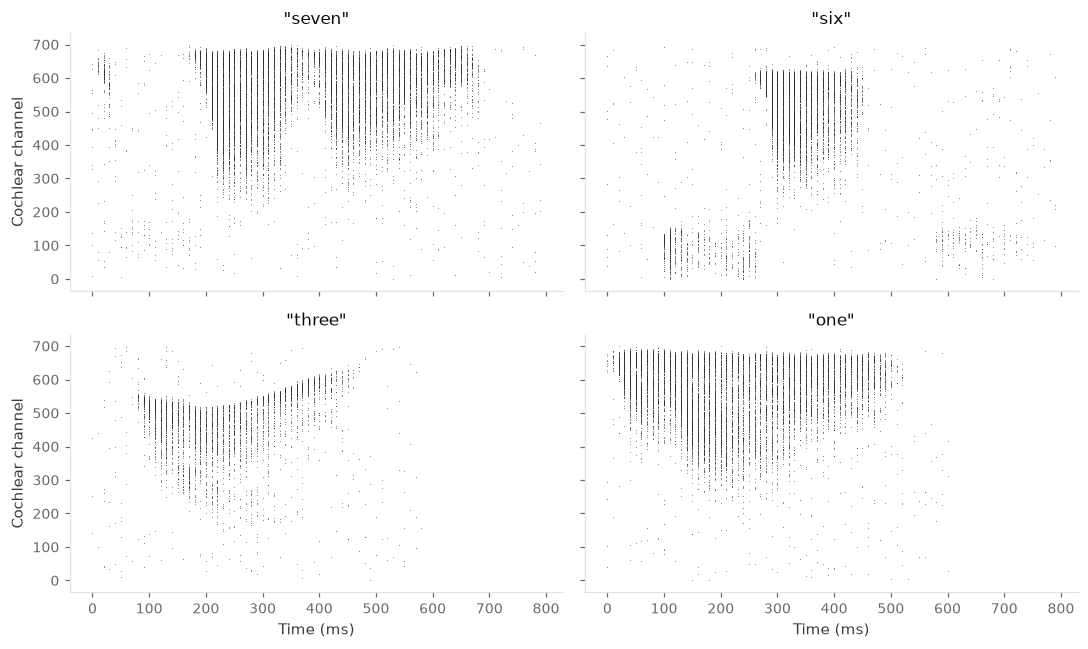

In [4]:
X, y, t = data.build_design_matrix(shd, bin_ms=10.0, t_max_ms=800.0)
print("X:", X.shape, "= (trials, channels, time bins)")

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
for ax, word in zip(axes.ravel(), ["seven", "six", "three", "one"]):
    trial = np.flatnonzero(shd.labels == data.DIGIT_KEYS.index(word))[0]
    plotting.raster(X, trial, ax=ax, bin_ms=10.0)
    ax.set_title(f'"{word}"')
for ax in axes[0]:
    ax.set_xlabel("")
for ax in axes[:, 1]:
    ax.set_ylabel("")
fig.tight_layout()
plotting.savefig(fig, "01_rasters", outdir="../plots")

Channel index is **tonotopic**: it maps monotonically onto frequency, because position along the modelled basilar membrane is set by the frequency that resonates there. The diagonal sweeps are formant transitions moving along that axis.

This is worth remembering — it means a neighbouring pair of channels is *related*, and any analysis that permutes channels destroys that. Sometimes destroying it is exactly the control you want.

## Class balance and trial duration

Two numbers that change what you do next.

duration  median 0.70 s   5-95% 0.52-0.96 s
fraction longer than 800 ms: 24.8%


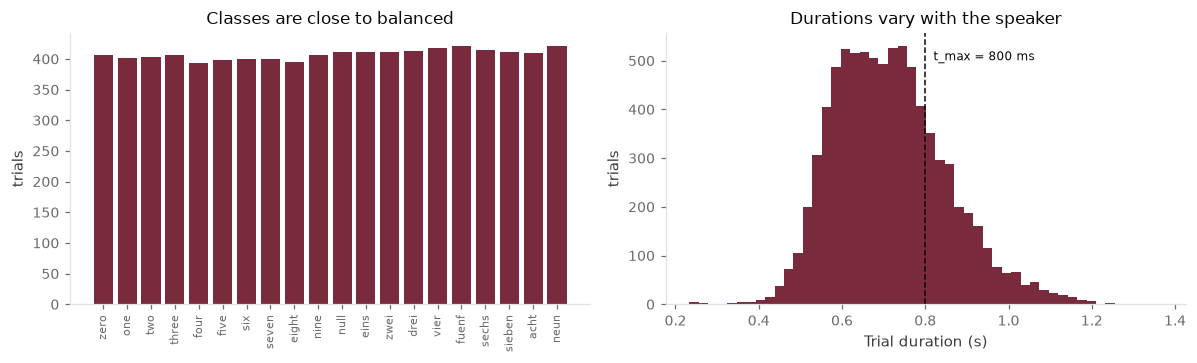

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

counts = np.bincount(shd.labels, minlength=20)
axes[0].bar(np.arange(20), counts, color=plotting.ACCENT, linewidth=0)
axes[0].set_xticks(np.arange(20))
axes[0].set_xticklabels(data.DIGIT_KEYS, rotation=90, fontsize=7)
axes[0].set_ylabel("trials")
axes[0].set_title("Classes are close to balanced")

durations = np.array([tt.max() for tt in shd.times])
axes[1].hist(durations, bins=50, color=plotting.ACCENT, linewidth=0)
axes[1].axvline(0.8, color=plotting.INK, ls="--", lw=1)
axes[1].text(0.81, axes[1].get_ylim()[1] * 0.9, " t_max = 800 ms", fontsize=8)
axes[1].set_xlabel("Trial duration (s)")
axes[1].set_ylabel("trials")
axes[1].set_title("Durations vary with the speaker")
fig.tight_layout()

print(f"duration  median {np.median(durations):.2f} s   5-95% {np.percentile(durations, 5):.2f}-{np.percentile(durations, 95):.2f} s")
print(f"fraction longer than 800 ms: {(durations > 0.8).mean():.1%}")

**This is the first real decision.** `t_max_ms` puts every trial on a common time base so they can be stacked. Truncating loses the end of long trials; zero-padding invents silence in short ones. Both distort the geometry you are about to measure.

Pick a value, say why, and check your final result survives a different one.

## Population statistics

overall sparsity: 10.9% of channel-time bins contain a spike


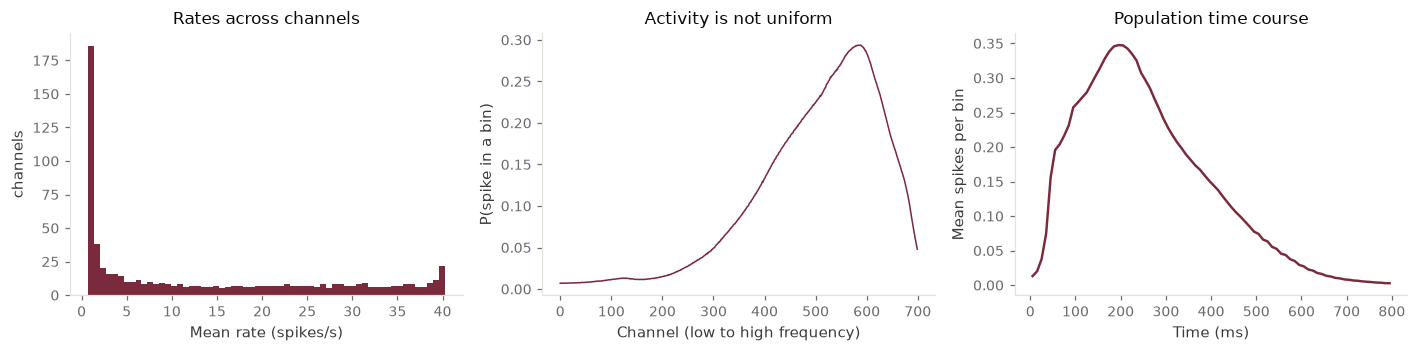

In [6]:
rates = data.rates(X, bin_ms=10.0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))

axes[0].hist(rates.mean(axis=0), bins=60, color=plotting.ACCENT, linewidth=0)
axes[0].set_xlabel("Mean rate (spikes/s)")
axes[0].set_ylabel("channels")
axes[0].set_title("Rates across channels")

axes[1].plot((X > 0).mean(axis=(0, 2)), color=plotting.ACCENT, lw=1)
axes[1].set_xlabel("Channel (low to high frequency)")
axes[1].set_ylabel("P(spike in a bin)")
axes[1].set_title("Activity is not uniform")

axes[2].plot(t, X.mean(axis=(0, 1)), color=plotting.ACCENT)
axes[2].set_xlabel("Time (ms)")
axes[2].set_ylabel("Mean spikes per bin")
axes[2].set_title("Population time course")
fig.tight_layout()

print(f"overall sparsity: {(X > 0).mean():.1%} of channel-time bins contain a spike")

## How similar are two utterances of the same digit?

This previews how hard the decoding problem is.

same digit       0.374
different digit  0.301


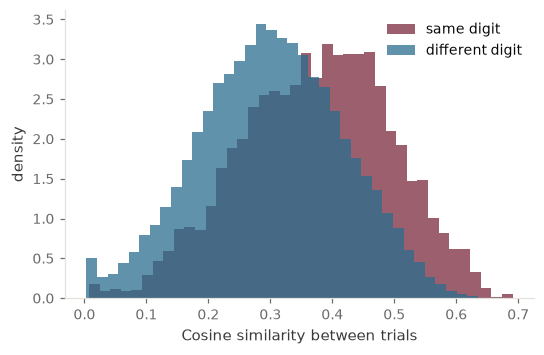

In [7]:
from scipy.spatial.distance import pdist, squareform

sub = rng.choice(len(shd), size=400, replace=False)
Xs = data.flatten(X[sub])
Xs = Xs / (np.linalg.norm(Xs, axis=1, keepdims=True) + 1e-9)
sim = 1 - squareform(pdist(Xs, metric="cosine"))
same = y[sub][:, None] == y[sub][None, :]
iu = np.triu_indices(len(sub), k=1)

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.hist(sim[iu][same[iu]], bins=40, alpha=0.75, density=True, linewidth=0, label="same digit")
ax.hist(sim[iu][~same[iu]], bins=40, alpha=0.75, density=True, linewidth=0, label="different digit")
ax.set_xlabel("Cosine similarity between trials")
ax.set_ylabel("density")
ax.legend()

print(f"same digit       {sim[iu][same[iu]].mean():.3f}")
print(f"different digit  {sim[iu][~same[iu]].mean():.3f}")

The two distributions are shifted but heavily overlapping. If they separated cleanly there would be nothing interesting left to do.

## The second decision: bin width

Bin width sets how much spike timing survives. Cramer et al. (2020) showed classifiers with no access to timing plateau near **60 %** accuracy while temporally aware ones reach **~85 %** — so this parameter places you somewhere on that axis.

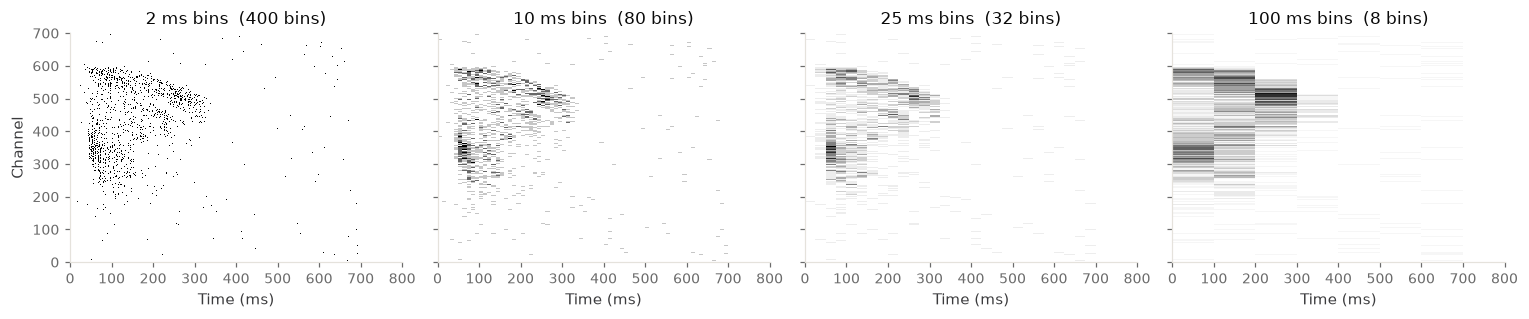

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for ax, b in zip(axes, [2.0, 10.0, 25.0, 100.0]):
    Xb, _, _ = data.build_design_matrix(shd, bin_ms=b, t_max_ms=800.0, trials=np.arange(1))
    ax.imshow(Xb[0], aspect="auto", origin="lower", cmap="Greys",
              extent=[0, 800, 0, Xb.shape[1]], interpolation="nearest")
    ax.set_title(f"{b:g} ms bins  ({Xb.shape[2]} bins)")
    ax.set_xlabel("Time (ms)")
axes[0].set_ylabel("Channel")
fig.tight_layout()

---

## Exercises

1. **Speakers.** Do some speakers produce systematically more spikes? If so, a classifier could learn the *speaker* rather than the digit. Check, and decide what to do about it.
2. **Languages.** Are the English digits closer to their German counterparts (e.g. `three` and `drei`) than to other digits?
3. **A surrogate control.** Shuffle spike times within each trial while keeping the per-channel spike counts fixed. Re-run the similarity analysis. How much separation survives? Keep this surrogate — it is the correct null for several later analyses.
4. **Commit to a `t_max_ms` and a `bin_ms`,** and write two sentences defending each.

Next: **[2 · Geometry](02_geometry.ipynb)** — what shape this population lives on.